# Extending pandas with a .bigquery accessor

Pandas provides [several extension points](https://pandas.pydata.org/docs/development/extending.html). BigQuery has been extending data types for a few years via the `db-dtypes` package. Recently, we also extended DataFrame and Series with a custom `.bigquery` accessor as part of the `bigframes` package.

```python
@pandas.api.extensions.register_dataframe_accessor("bigquery")
class PandasBigQueryDataFrameAccessor(BigQueryDataFrameAccessor[T, S]):
    def __init__(self, pandas_obj: T):
        super().__init__(pandas_obj)
    
    @property
    def ai(self) -> PandasAIAccessor:
        ...


@pandas.api.extensions.register_series_accessor("bigquery")
class PandasBigQuerySeriesAccessor(core_accessor.BigQuerySeriesAccessor[T, S]):
    def __init__(self, pandas_obj: S):
        super().__init__(pandas_obj)
    
    @property
    def ai(self) -> PandasAiSeriesAccessor[T, S]:
        ...

    @property
    def aead(self) -> PandasAeadSeriesAccessor[T, S]:
        ...
```

## Why?

BigQuery provides [hundreds of functions built-in](https://docs.cloud.google.com/bigquery/docs/reference/standard-sql/functions-all) that run "serverless" in the cloud. There is also an extensive ecosystem of like public cloud-hosted UDFs. Use these functions from pandas in a way that feels native.

## Demo: TimesFM

Use the Google TimesFM model on USDA wheat data.

In [17]:
import bigframes  # Adds a .bigquery accessor to DataFrame and Series
import pandas as pd

wheat = pd.read_csv("wheat.csv", dtype_backend="pyarrow").assign(
    year=lambda df: pd.to_datetime(df['year'])).set_index("year")
wheat

,Time period,Beginning stocks,Production,Imports 2,Total supply 3,Food use,Seed use,Feed and residual use,Total domestic use 3,Exports 2,Total disappearance 3,Ending stocks
year,,,,,,,,,,,,
1950-01-01 00:00:00+00:00,MY Jun-May,496.0,1019.0,11.0,1526.0,580.0,--,109.0,689.0,345.0,1034.0,492.0
1951-01-01 00:00:00+00:00,MY Jun-May,492.0,988.0,30.0,1510.0,585.0,--,110.0,695.0,485.0,1180.0,330.0
1952-01-01 00:00:00+00:00,MY Jun-May,330.0,1306.0,24.0,1660.0,578.0,--,78.0,656.0,332.0,988.0,672.0
1953-01-01 00:00:00+00:00,MY Jun-May,672.0,1173.0,6.0,1851.0,556.0,--,87.0,643.0,214.0,857.0,994.0
1954-01-01 00:00:00+00:00,MY Jun-May,994.0,984.0,3.0,1981.0,552.0,--,53.0,605.0,267.0,872.0,1109.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-01 00:00:00+00:00,MY Jun-May,674.431,1649.713,121.585,2445.729,971.677,68.369,75.503,1115.549,760.612,1876.161,569.568
2023-01-01 00:00:00+00:00,MY Jun-May,569.568,1803.942,137.798,2511.308,961.303,62.046,85.617,1108.966,705.908,1814.874,696.434
2024-01-01 00:00:00+00:00,MY Jun-May,696.434,1978.697,149.63,2824.761,969.242,61.1,110.857,1141.199,828.828,1970.027,854.734


In [18]:
forecast = (
    wheat
    .reset_index(drop=False)
    .bigquery.ai.forecast(
        data_col="Production",
        timestamp_col="year",
        horizon=10,
    )
)

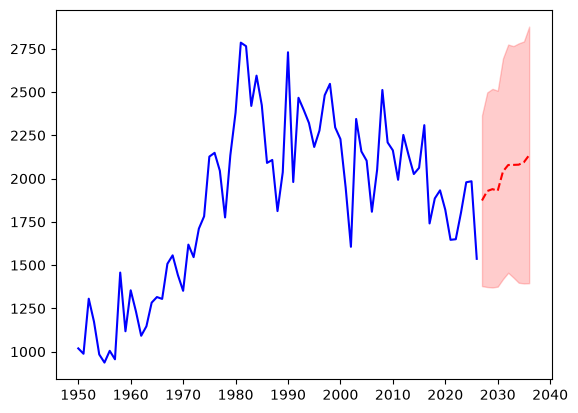

In [19]:
import matplotlib.pyplot as plt

# Plot the results
forecast_sorted = forecast.sort_values(by='forecast_timestamp')
plt.plot(wheat.index, wheat['Production'], label='Real Production', color='blue')
plt.plot(forecast_sorted['forecast_timestamp'], forecast_sorted['forecast_value'], label='Forecasted Production', color='red', linestyle='--')
plt.fill_between(
   forecast_sorted['forecast_timestamp'],
   forecast_sorted['prediction_interval_lower_bound'],
   forecast_sorted['prediction_interval_upper_bound'],
   color='red',
   alpha=0.2,
   label='Confidence Interval'
)
plt.show()

## Demo: BigQuery UDFs

Use functions that have been deployed to BigQuery even if they have requirements that can't easily be installed locally. There are several projects that have deployed functions already, including:

- [Google Cloud Professional Services' BigQuery Utils](https://github.com/GoogleCloudPlatform/bigquery-utils/tree/master)
- [Unytics BigFunctions](https://unytics.io/bigfunctions/)
- [CARTO Analytics Toolbox](https://docs.carto.com/data-and-analysis/analytics-toolbox-for-bigquery)

In [23]:
df = pd.DataFrame({"x": [1, 2, 3]})
df.bigquery.sql_scalar("`bqutil`.fn.cw_setbit({x}, 2)")


0    5
1    6
2    7
dtype: Int64